In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

C:\Users\PEPI\Documents\Downloads\tess_env\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
search_result = lk.search_lightcurve('TIC 149990841', mission='TESS', author='SPOC')
print(search_result)

SearchResult containing 35 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 09 2019   SPOC     120   149990841      0.0
  1 TESS Sector 11 2019   SPOC     120   149990841      0.0
  2 TESS Sector 12 2019   SPOC     120   149990841      0.0
  3 TESS Sector 27 2020   SPOC      20   149990841      0.0
  4 TESS Sector 28 2020   SPOC      20   149990841      0.0
  5 TESS Sector 29 2020   SPOC      20   149990841      0.0
  6 TESS Sector 31 2020   SPOC      20   149990841      0.0
  7 TESS Sector 32 2020   SPOC      20   149990841      0.0
  8 TESS Sector 27 2020   SPOC     120   149990841      0.0
  9 TESS Sector 28 2020   SPOC     120   149990841      0.0
 10 TESS Sector 29 2020   SPOC     120   149990841      0.0
 11 TESS Sector 31 2020   SPOC     120   149990841      0.0
 12 TESS Sector 32 2020   SPOC     120   149990841      0

In [3]:
mask = search_result.exptime.value == 120
filtered_result = search_result[mask]
print(filtered_result)

SearchResult containing 25 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 09 2019   SPOC     120   149990841      0.0
  1 TESS Sector 11 2019   SPOC     120   149990841      0.0
  2 TESS Sector 12 2019   SPOC     120   149990841      0.0
  3 TESS Sector 27 2020   SPOC     120   149990841      0.0
  4 TESS Sector 28 2020   SPOC     120   149990841      0.0
  5 TESS Sector 29 2020   SPOC     120   149990841      0.0
  6 TESS Sector 31 2020   SPOC     120   149990841      0.0
  7 TESS Sector 32 2020   SPOC     120   149990841      0.0
  8 TESS Sector 34 2021   SPOC     120   149990841      0.0
  9 TESS Sector 35 2021   SPOC     120   149990841      0.0
 10 TESS Sector 37 2021   SPOC     120   149990841      0.0
 11 TESS Sector 38 2021   SPOC     120   149990841      0.0
 12 TESS Sector 39 2021   SPOC     120   149990841      0

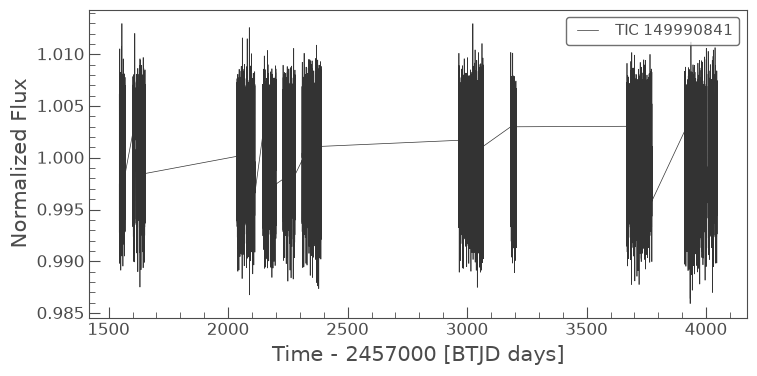

In [4]:
lc_collection = filtered_result.download_all()
lc = lc_collection.stitch().remove_nans().remove_outliers(sigma=6)
lc.plot()
plt.show()

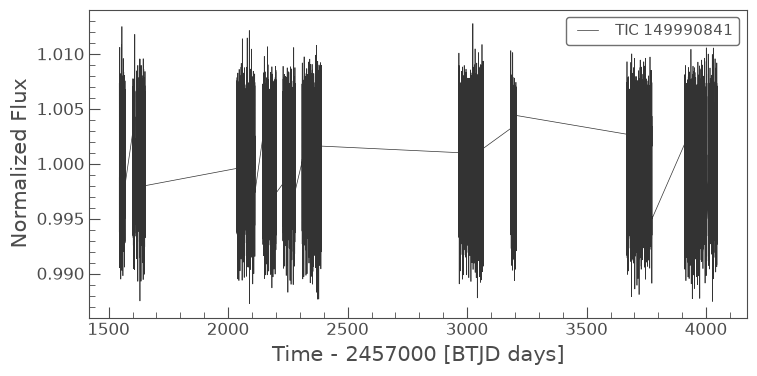

In [5]:
flat_lc = lc.flatten(window_length=901)
flat_lc.plot()
plt.show()

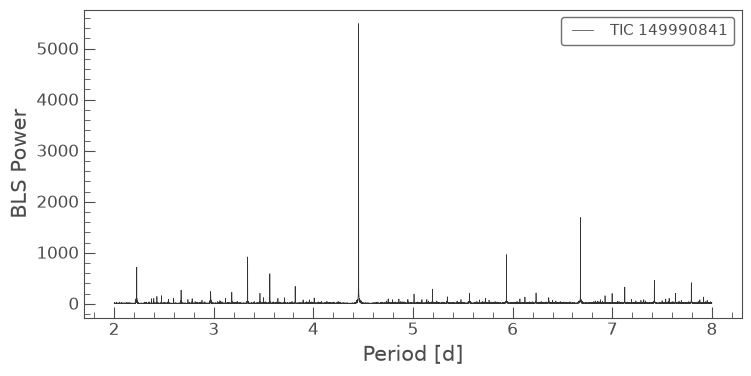

In [6]:
period_grid = np.linspace(2, 8, 10000)
periodogram = flat_lc.to_periodogram(method='bls', period=period_grid, frequency_factor=500)
periodogram.plot()
plt.show()

In [7]:
best_period = periodogram.period_at_max_power
best_t0 = periodogram.transit_time_at_max_power
best_duration = periodogram.duration_at_max_power

print(f"Best period: {best_period}")
print(f"Best transit time (t0): {best_t0}")
print(f"Best duration: {best_duration}")

Best period: 4.453045304530454 d
Best transit time (t0): 1546.28350224908
Best duration: 0.1 d


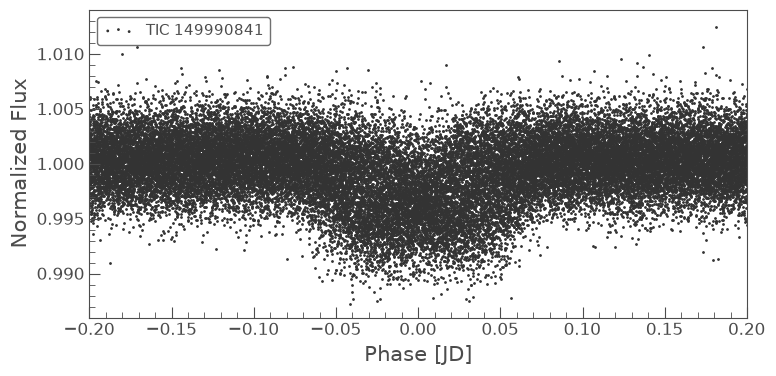

In [8]:
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_t0)
folded_lc.scatter()
plt.xlim(-0.2, 0.2)
plt.show()

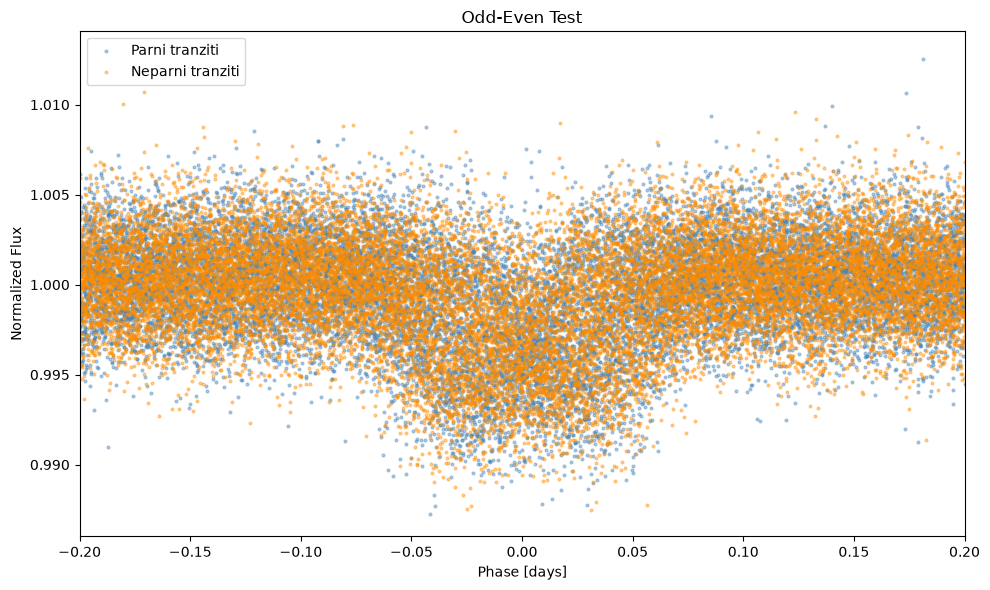

In [9]:
cycle_number = np.round((flat_lc.time.value - best_t0.value) / best_period.value)

even_mask = cycle_number % 2 == 0
odd_mask = cycle_number % 2 == 1

even_lc = flat_lc[even_mask]
odd_lc = flat_lc[odd_mask]

even_folded = even_lc.fold(period=best_period, epoch_time=best_t0)
odd_folded = odd_lc.fold(period=best_period, epoch_time=best_t0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(even_folded.phase.value, even_folded.flux.value,
           s=4, color='steelblue', alpha=0.4, label='Parni tranziti')
ax.scatter(odd_folded.phase.value, odd_folded.flux.value,
           s=4, color='darkorange', alpha=0.4, label='Neparni tranziti')
ax.set_xlim(-0.2, 0.2)
ax.set_xlabel('Phase [days]')
ax.set_ylabel('Normalized Flux')
ax.set_title('Odd-Even Test')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
tpf_search = lk.search_targetpixelfile('TIC 149990841', mission='TESS', author='SPOC', exptime=120)
print(tpf_search)

SearchResult containing 25 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 09 2019   SPOC     120   149990841      0.0
  1 TESS Sector 11 2019   SPOC     120   149990841      0.0
  2 TESS Sector 12 2019   SPOC     120   149990841      0.0
  3 TESS Sector 27 2020   SPOC     120   149990841      0.0
  4 TESS Sector 28 2020   SPOC     120   149990841      0.0
  5 TESS Sector 29 2020   SPOC     120   149990841      0.0
  6 TESS Sector 31 2020   SPOC     120   149990841      0.0
  7 TESS Sector 32 2020   SPOC     120   149990841      0.0
  8 TESS Sector 34 2021   SPOC     120   149990841      0.0
  9 TESS Sector 35 2021   SPOC     120   149990841      0.0
 10 TESS Sector 37 2021   SPOC     120   149990841      0.0
 11 TESS Sector 38 2021   SPOC     120   149990841      0.0
 12 TESS Sector 39 2021   SPOC     120   149990841      0

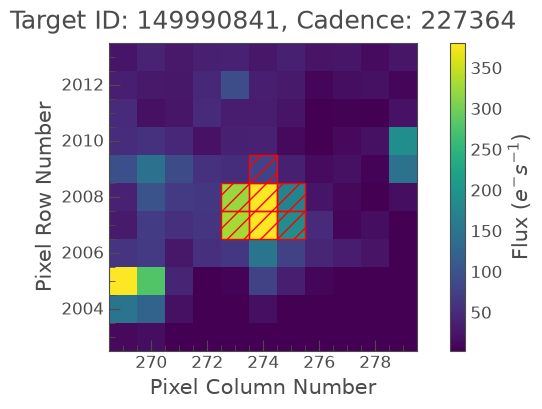

In [12]:
tpf = tpf_search[0].download()
tpf.plot(aperture_mask=tpf.pipeline_mask)
plt.show()

In [13]:
print(tpf.shape)

(17122, 11, 11)


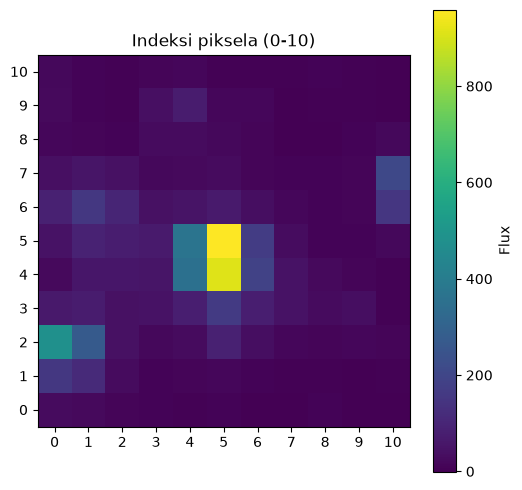

In [14]:
mean_image = np.nanmean(tpf.flux.value, axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(mean_image, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label='Flux')
ax.set_xticks(range(11))
ax.set_yticks(range(11))
ax.set_title('Indeksi piksela (0-10)')
plt.show()

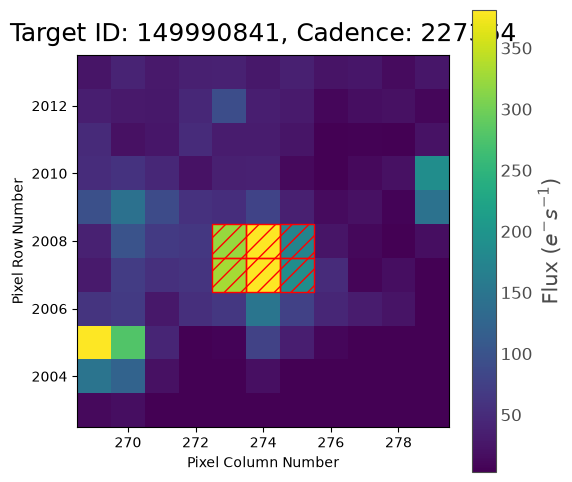

In [15]:
custom_mask = np.zeros(tpf.shape[1:], dtype=bool)
custom_mask[4:6, 4:7] = True

fig, ax = plt.subplots(figsize=(6, 6))
tpf.plot(ax=ax, aperture_mask=custom_mask)
plt.show()

In [16]:
tpf_search_full = lk.search_targetpixelfile('TIC 149990841', mission='TESS', author='SPOC', exptime=120)
tpf_collection = tpf_search_full[0:5].download_all()

In [17]:
all_centroid_col = []
all_centroid_row = []
all_time = []

for tpf_item in tpf_collection:
    c_col, c_row = tpf_item.estimate_centroids(aperture_mask=tpf_item.pipeline_mask)
    all_centroid_col.append(c_col.value)
    all_centroid_row.append(c_row.value)
    all_time.append(tpf_item.time.value)

all_centroid_col = np.concatenate(all_centroid_col)
all_centroid_row = np.concatenate(all_centroid_row)
all_time = np.concatenate(all_time)

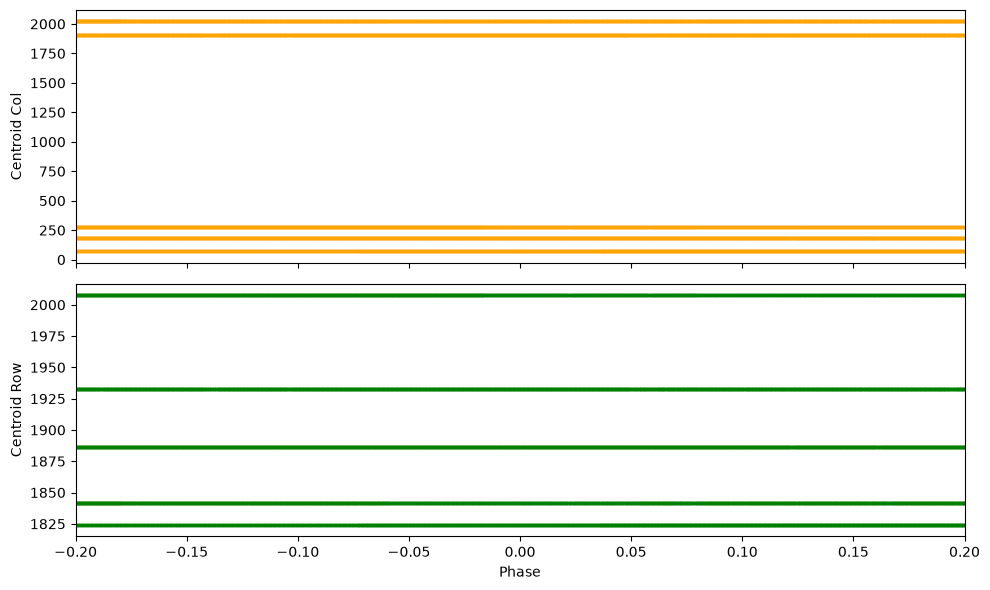

In [18]:
phase = ((all_time - best_t0.value) / best_period.value) % 1
phase[phase > 0.5] -= 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].scatter(phase, all_centroid_col, s=2, color='orange', alpha=0.5)
axes[0].set_ylabel('Centroid Col')
axes[0].set_xlim(-0.2, 0.2)

axes[1].scatter(phase, all_centroid_row, s=2, color='green', alpha=0.5)
axes[1].set_ylabel('Centroid Row')
axes[1].set_xlabel('Phase')
axes[1].set_xlim(-0.2, 0.2)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
R_star_solar = (1.09 + 1.14) / 2
transit_depth = 0.01
R_planet_solar = R_star_solar * np.sqrt(transit_depth)

R_sun_to_earth = 109.2
R_planet_earth = R_planet_solar * R_sun_to_earth
R_jupiter_earth = 11.2

print(f"Prosjecni radijus zvijezde: {R_star_solar:.3f} R_Sun")
print(f"Procijenjeni radijus planeta: {R_planet_solar:.4f} R_Sun")
print(f"Procijenjeni radijus planeta: {R_planet_earth:.2f} R_Earth")
print(f"Procijenjeni radijus planeta: {R_planet_earth / R_jupiter_earth:.2f}x R_Jupyter")

Prosjecni radijus zvijezde: 1.115 R_Sun
Procijenjeni radijus planeta: 0.1115 R_Sun
Procijenjeni radijus planeta: 12.18 R_Earth
Procijenjeni radijus planeta: 1.09x R_Jupyter
